“Can we predict whether a test case will Pass or Fail?"

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

data=pd.read_excel(r"C:\Users\bhanu\Downloads\test_data.xlsx")
df= pd.DataFrame(data)
df

,test_case,status,module,date
0,TC1,Pass,Login,2024-01-01
1,TC2,Fail,Cart,2024-01-02
2,TC3,Pass,Login,2024-01-03
3,TC4,Fail,Payment,2024-01-04
4,TC5,Fail,Cart,2024-01-05
5,TC6,Pass,Payment,2024-01-06
6,TC7,Fail,Login,2024-01-07
7,TC8,Pass,Cart,2024-01-08
8,TC9,Fail,Payment,2024-01-09
9,TC10,Pass,Login,2024-01-10


In [9]:
df['status'] = df['status'].map({"pass":1,"Fail":0})

In [11]:
df

,test_case,status,module,date
0,TC1,NaN,Login,2024-01-01
1,TC2,0.0,Cart,2024-01-02
2,TC3,NaN,Login,2024-01-03
3,TC4,0.0,Payment,2024-01-04
4,TC5,0.0,Cart,2024-01-05
5,TC6,NaN,Payment,2024-01-06
6,TC7,0.0,Login,2024-01-07
7,TC8,NaN,Cart,2024-01-08
8,TC9,0.0,Payment,2024-01-09
9,TC10,NaN,Login,2024-01-10


In [13]:
df['status']=df['status'].fillna(1)

In [15]:
df

,test_case,status,module,date
0,TC1,1.0,Login,2024-01-01
1,TC2,0.0,Cart,2024-01-02
2,TC3,1.0,Login,2024-01-03
3,TC4,0.0,Payment,2024-01-04
4,TC5,0.0,Cart,2024-01-05
5,TC6,1.0,Payment,2024-01-06
6,TC7,0.0,Login,2024-01-07
7,TC8,1.0,Cart,2024-01-08
8,TC9,0.0,Payment,2024-01-09
9,TC10,1.0,Login,2024-01-10


In [19]:
df['status'].dtype

dtype('float64')

In [23]:
df['test_case'].dtype

dtype('O')

In [25]:
df['module'].dtype

dtype('O')

In [31]:
df['date'].dtype #what is this dtype

dtype('<M8[ns]')

In [33]:
df=pd.get_dummies(df,columns=['module'],drop_first=True)

In [35]:
df

,test_case,status,date,module_Login,module_Payment
0,TC1,1.0,2024-01-01,True,False
1,TC2,0.0,2024-01-02,False,False
2,TC3,1.0,2024-01-03,True,False
3,TC4,0.0,2024-01-04,False,True
4,TC5,0.0,2024-01-05,False,False
5,TC6,1.0,2024-01-06,False,True
6,TC7,0.0,2024-01-07,True,False
7,TC8,1.0,2024-01-08,False,False
8,TC9,0.0,2024-01-09,False,True
9,TC10,1.0,2024-01-10,True,False


In [57]:
df['module_Login'].dtype

dtype('bool')

In [69]:
df["date"] = pd.to_datetime(df["date"])

df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.weekday   # 0 = Monday

In [75]:
#define features and target

X= df.drop(['status','test_case','date'],axis=1)
y=df['status']

In [77]:
X

,module_Login,module_Payment,day,month,weekday
0,True,False,1,1,0
1,False,False,2,1,1
2,True,False,3,1,2
3,False,True,4,1,3
4,False,False,5,1,4
5,False,True,6,1,5
6,True,False,7,1,6
7,False,False,8,1,0
8,False,True,9,1,1
9,True,False,10,1,2


In [79]:
y

0    1.0
1    0.0
2    1.0
3    0.0
4    0.0
5    1.0
6    0.0
7    1.0
8    0.0
9    1.0
Name: status, dtype: float64

********Logistic Regression********

In [81]:
#Train model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3) #split test and train data

model=LogisticRegression()
model.fit(X_train,y_train) #how to convert date and test_case

LogisticRegression()

In [67]:
X_train

,date,module_Login,module_Payment
9,2024-01-10,True,False
5,2024-01-06,False,True
2,2024-01-03,True,False
1,2024-01-02,False,False
8,2024-01-09,False,True
3,2024-01-04,False,True
7,2024-01-08,False,False


In [51]:
y_train

9    1.0
4    0.0
8    0.0
1    0.0
5    1.0
2    1.0
3    0.0
Name: status, dtype: float64

syntax for mean: df["execution_time"].fillna(df["execution_time"].mean(), inplace=True)

In [83]:
y_pred= model.predict(X_test)

In [85]:
from sklearn.metrics import accuracy_score

print('Accuracy',accuracy_score(y_test,y_pred))

Accuracy 0.3333333333333333


In [87]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.5
Recall: 0.5
F1 Score: 0.5


In [89]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         1
         1.0       0.50      0.50      0.50         2

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [91]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[0 1]
 [1 1]]


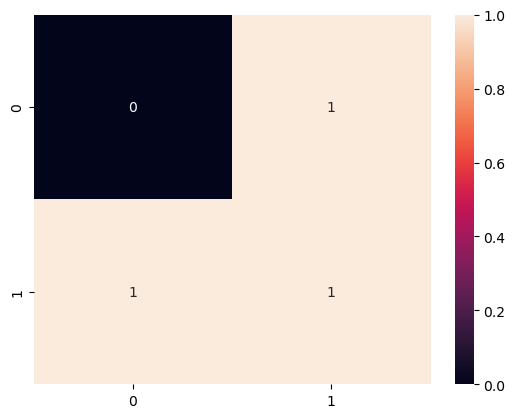

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [95]:
#feature importance
coeff = model.coef_[0]

features = X.columns

for f, c in zip(features, coeff):
    print(f, c)

module_Login 0.5361857855144408
module_Payment -0.6240598967881681
day 0.046261793763555936
month 0.0006357659416473841
weekday -0.8115324383059118


In [97]:
#sort by impact

importance = pd.DataFrame({
    "feature": X.columns,
    "weight": model.coef_[0]
})

importance = importance.sort_values(by="weight", ascending=False)

print(importance)

          feature    weight
0    module_Login  0.536186
2             day  0.046262
3           month  0.000636
1  module_Payment -0.624060
4         weekday -0.811532


<Axes: xlabel='feature'>

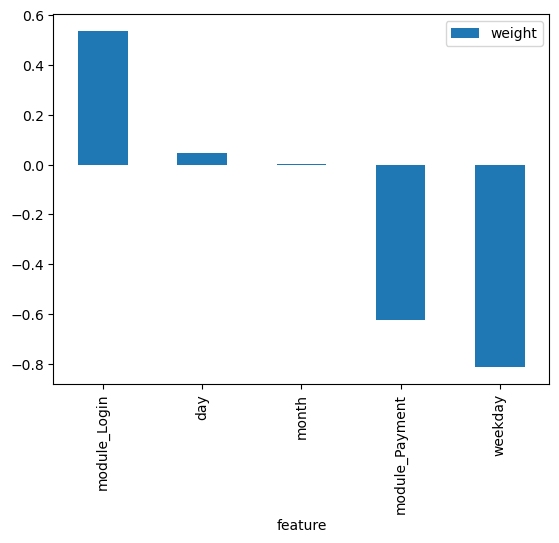

In [99]:
#plot graph

importance.plot(kind="bar", x="feature", y="weight")

In [101]:
probs = model.predict_proba(X_test)

print(probs[:5])

[[0.49006114 0.50993886]
 [0.96820999 0.03179001]
 [0.43319054 0.56680946]]


*******************Decision Tree*******************

In [103]:
from sklearn.tree import DecisionTreeClassifier

model =DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred= model.predict(X_test)

In [105]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         1
         1.0       0.50      0.50      0.50         2

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



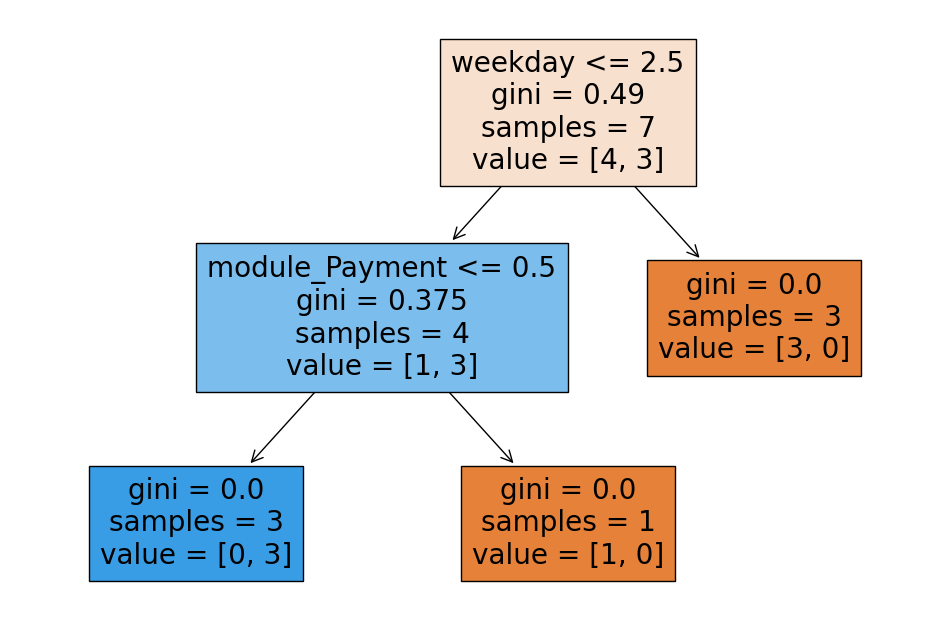

In [114]:
#visualize

from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(model,feature_names=X.columns,filled=True)#filled is to add colors
plt.show()

If weekday is > 2.5, then fail
If Weekday is <=2.5 and module != payment then 3 pass
If Weekday is <=2.5 and module = payment then 1 fail
Value [Fail,Pass]


In [111]:
#feature importance

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

print(importance.sort_values(by="importance", ascending=False))

          feature  importance
4         weekday      0.5625
1  module_Payment      0.4375
0    module_Login      0.0000
2             day      0.0000
3           month      0.0000


*********************Random Forest*********************

In [126]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(n_estimators=100, max_depth=5,
    random_state=42)
model.fit(X_train,y_train)
y_pred= model.predict(X_test)

In [128]:
report= classification_report(y_pred,y_test)
print(report)

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         1
         1.0       0.50      0.50      0.50         2

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



In [130]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(by="importance", ascending=False)
print(importance)

          feature  importance
4         weekday    0.489297
2             day    0.284681
1  module_Payment    0.152994
0    module_Login    0.073028
3           month    0.000000


Predict Bug Prone Modules

In [150]:
import pandas as pd
import matplotlib.pyplot as plt

data1=pd.read_excel(r"C:\Users\bhanu\Downloads\test_data.xlsx")
df1= pd.DataFrame(data1)
df1


,test_case,status,module,date
0,TC1,Pass,Login,2024-01-01
1,TC2,Fail,Cart,2024-01-02
2,TC3,Pass,Login,2024-01-03
3,TC4,Fail,Payment,2024-01-04
4,TC5,Fail,Cart,2024-01-05
5,TC6,Pass,Payment,2024-01-06
6,TC7,Fail,Login,2024-01-07
7,TC8,Pass,Cart,2024-01-08
8,TC9,Fail,Payment,2024-01-09
9,TC10,Pass,Login,2024-01-10


In [152]:
df1['status']= df1['status'].str.strip()

In [154]:
df1['status']= df1['status'].map({'Pass':0,'Fail':1})

In [156]:
df1

,test_case,status,module,date
0,TC1,0,Login,2024-01-01
1,TC2,1,Cart,2024-01-02
2,TC3,0,Login,2024-01-03
3,TC4,1,Payment,2024-01-04
4,TC5,1,Cart,2024-01-05
5,TC6,0,Payment,2024-01-06
6,TC7,1,Login,2024-01-07
7,TC8,0,Cart,2024-01-08
8,TC9,1,Payment,2024-01-09
9,TC10,0,Login,2024-01-10


In [164]:
#calculate failure per module

module_fail_rate = df1.groupby("module")["status"].mean().sort_values(ascending=False)
print(module_fail_rate)

module
Cart       0.666667
Payment    0.666667
Login      0.250000
Name: status, dtype: float64


In [166]:
def risk_label(x):
    if x > 0.6:
        return "High"
    elif x > 0.3:
        return "Medium"
    else:
        return "Low"

module_risk = module_fail_rate.apply(risk_label)
print(module_risk)

module
Cart       High
Payment    High
Login       Low
Name: status, dtype: object


In [168]:
module_df = module_risk.reset_index()
module_df.columns = ["module", "risk"]

In [170]:
module_df = pd.get_dummies(module_df, columns=["module"])

In [172]:
module_df

,risk,module_Cart,module_Login,module_Payment
0,High,True,False,False
1,High,False,False,True
2,Low,False,True,False


In [174]:
from sklearn.ensemble import RandomForestClassifier

X = module_df.drop("risk", axis=1)
y = module_df["risk"]

model = RandomForestClassifier()
model.fit(X, y)

RandomForestClassifier()

In [192]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [194]:
y_pred=model.predict(X_test)

In [196]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



Precision = Correct Fail Predictions / Total Predicted Fail
Recall = Correct Fail Predictions / Total Actual Fail
F1 = 2 * (Precision * Recall) / (Precision + Recall)


In all the above cases, the data used in inadequate , hence the model's accuracy are not perfect. It is only for learning purpose.

****************************ANAMOLY DETECTION***************************

In [214]:
#Which test executions look unusual or suspicious?

import pandas as pd

data2 = {
    "test_case": ["TC1","TC2","TC3","TC4","TC5","TC6","TC7","TC8","TC9","TC10","TC11","TC12","TC13","TC14","TC15","TC16"],
    "module": ["Login","Login","Login","Search","Search","Search","Payment","Payment","Payment","Login","Search","Payment","Login","Search","Payment","Login"],
    "execution_time": [2,3,2.5,4,5,4.5,6,7,6.5,2.2,4.2,6.8,15,20,1,0.5],
    "weekday": [1,2,1,2,3,2,3,4,3,1,2,4,1,2,3,2]
}

df2 = pd.DataFrame(data2)

print(df2)


   test_case   module  execution_time  weekday
0        TC1    Login             2.0        1
1        TC2    Login             3.0        2
2        TC3    Login             2.5        1
3        TC4   Search             4.0        2
4        TC5   Search             5.0        3
5        TC6   Search             4.5        2
6        TC7  Payment             6.0        3
7        TC8  Payment             7.0        4
8        TC9  Payment             6.5        3
9       TC10    Login             2.2        1
10      TC11   Search             4.2        2
11      TC12  Payment             6.8        4
12      TC13    Login            15.0        1
13      TC14   Search            20.0        2
14      TC15  Payment             1.0        3
15      TC16    Login             0.5        2


In [218]:
features = df2[['execution_time','weekday']]

In [220]:

from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.2)#contamination = expected % of anomalies
model.fit(features)

IsolationForest(contamination=0.2)

In [224]:
df2["anomaly"] = model.fit_predict(features)

print(df2)

   test_case   module  execution_time  weekday  anomaly
0        TC1    Login             2.0        1        1
1        TC2    Login             3.0        2        1
2        TC3    Login             2.5        1        1
3        TC4   Search             4.0        2        1
4        TC5   Search             5.0        3        1
5        TC6   Search             4.5        2        1
6        TC7  Payment             6.0        3        1
7        TC8  Payment             7.0        4       -1
8        TC9  Payment             6.5        3        1
9       TC10    Login             2.2        1        1
10      TC11   Search             4.2        2        1
11      TC12  Payment             6.8        4        1
12      TC13    Login            15.0        1       -1
13      TC14   Search            20.0        2       -1
14      TC15  Payment             1.0        3        1
15      TC16    Login             0.5        2        1


In [228]:
anomalies = df2[df2["anomaly"] == -1]
print(anomalies)

   test_case   module  execution_time  weekday  anomaly
7        TC8  Payment             7.0        4       -1
12      TC13    Login            15.0        1       -1
13      TC14   Search            20.0        2       -1


Note: Syntax is always same for all the models 